In [27]:
import pandas as pd
import yaml
import os

DATA_DIR = "D:\\data\\DATA1"

users_path = os.path.join(DATA_DIR, "users.csv")
users_df = pd.read_csv(users_path)
users_df = users_df.drop_duplicates()

orders_path = os.path.join(DATA_DIR, "orders.parquet")
orders_df = pd.read_parquet(orders_path)
orders_df = orders_df.drop_duplicates()

books_path = os.path.join(DATA_DIR, "books.yaml")
with open(books_path, 'r') as file:
    books_data = yaml.safe_load(file)

books_df = pd.DataFrame(books_data)
books_df.columns = [col.strip(':') if isinstance(col, str) else col for col in books_df.columns]
books_df = books_df.drop_duplicates()

print("Users shape:", users_df.shape)
print("Orders shape:", orders_df.shape)
print("Books shape:", books_df.shape)

Users shape: (3293, 5)
Orders shape: (11237, 7)
Books shape: (753, 6)


In [28]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3293 entries, 0 to 3292
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       3293 non-null   int64 
 1   name     3293 non-null   object
 2   address  3177 non-null   object
 3   phone    3293 non-null   object
 4   email    3293 non-null   object
dtypes: int64(1), object(4)
memory usage: 128.8+ KB


In [31]:
users_df['address'] = users_df['address'].fillna('Unknown')

In [32]:
count = users_df.isna().sum()
print(count)

id         0
name       0
address    0
phone      0
email      0
dtype: int64


In [30]:
count1 = (users_df.values =="").sum()
count2 = (users_df.values=="NULL").sum()
print(count1)
print(count2)

0
0


In [33]:
users_df

,id,name,address,phone,email
0,44533,Hoyt Carter,"Apt. 300 8604 Ashlyn Wells, Effertzstad, ID 02997",(462) 385-4294,mckinley.rowe@harber.example
1,46128,Marco Kulas,"Apt. 538 816 Bechtelar Ferry, Lincolnhaven, KS...",913.466.4487,francisco@murray-cronin.test
2,46407,Denny Goyette LLD,"Apt. 174 39450 Mohr Rapids, Port Neomistad, AL...",(801) 970-3335,marguerita@wuckert.test
3,44602,Zackary Heller,"Apt. 608 74228 Bogan Valley, South Stepanieshi...",895.829.5417,annabelle@hessel.test
4,45828,Jess Beier,"2716 Jacobi Path, Ziemanntown, SC 65624-4660",(113) 784-3410,minh@hettinger.example
...,...,...,...,...,...
3288,45131,Dr. Dulce Welch,"7640 Reichel Island, Swaniawskichester, VA 384...",397-216-6952,deetta_hilll@schaden.test
3289,44840,Ted Aufderhar Esq.,Unknown,424 718 8383,shella.pouros@murazik.example
3290,45538,Irmgard Erdman,Unknown,178.866.0267,dana@leuschke.example
3291,45097,Makeda Schmeler Ret.,"Suite 412 6556 Arnold Turnpike, Cummerataview,...",784.918.2549,daren_haag@kling.example


In [34]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11237 entries, 0 to 11236
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          11237 non-null  int64 
 1   user_id     11237 non-null  int64 
 2   book_id     11237 non-null  int64 
 3   quantity    11237 non-null  int32 
 4   unit_price  11237 non-null  object
 5   timestamp   11237 non-null  object
 6   shipping    8427 non-null   object
dtypes: int32(1), int64(3), object(3)
memory usage: 570.8+ KB


In [35]:
count1 = (orders_df['shipping']=="").sum()
count2 = (orders_df['shipping']=="NULL").sum()
count3 = orders_df['shipping'].isna().sum()
print(count1)
print(count2)
print(count3)

2799
2776
2810


In [36]:
import numpy as np
orders_df = orders_df.replace("", np.nan)
orders_df = orders_df.replace("NULL", np.nan)

In [37]:
count4 = orders_df.isna().sum()
print(count4)

id               0
user_id          0
book_id          0
quantity         0
unit_price       0
timestamp        0
shipping      8385
dtype: int64


In [38]:
orders_df['shipping'] = orders_df['shipping'].fillna('Unknown')

In [39]:
from dateutil import parser
orders_df['date'] = orders_df['timestamp'].apply(
    lambda x: parser.parse(x.replace(';', ' ').replace(',', ' ')).date() if pd.notnull(x) else pd.NaT
)

c:\Users\Samiz\anaconda3\envs\myenv\Lib\site-packages\dateutil\parser\_parser.py:1207: UnknownTimezoneWarning: tzname M identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


In [40]:
orders_df

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,date
0,71389,47288,18976,2,27.00$,10/01/24 10:38:08 A.M.,Unknown,2024-10-01
1,66343,47049,19403,1,€50¢50,10:14;19-Oct-2024,"4940 Arnoldo Keys, West Arnette, KS 77599",2024-10-19
2,72606,46685,19500,1,USD 45.99,"22:13:35,2025-07-02",Unknown,2025-07-02
3,68462,45336,18992,1,€ 71.00,2025-10-20 16:25:20,Unknown,2025-10-20
4,72691,45311,19388,1,52.25 $,"08:48:47 A.M.,28-August-2024",Unknown,2024-08-28
...,...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,57.99 EUR,04:51:02;04/06/25,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2...",2025-04-06
11233,72164,46481,18864,2,$71¢00,12:38:25 A.M. 2024-06-20,Unknown,2024-06-20
11234,70697,44686,19083,5,€50.,"11-Dec-2024, 14:52",Unknown,2024-12-11
11235,64646,46203,19190,1,44.75USD,11:09;05/17/25,Unknown,2025-05-17


In [41]:
import re
import pandas as pd

def convert_to_usd(price_val):
    if pd.isna(price_val):
        return 0.0
        
    price_str = str(price_val).strip()
    is_euro = '€' in price_str or 'EUR' in price_str.upper()
    price_str = re.sub(r'(\d+)[$¢€](\d+)¢?', r'\1.\2', price_str)
    numeric_str = re.sub(r'[^\d.]', '', price_str)

    if not numeric_str:
        return 0.0

    if is_euro:
        val = float(numeric_str) * 1.2
    else:
        val = float(numeric_str)
        
    return val

orders_df['unit_price_usd'] = orders_df['unit_price'].apply(convert_to_usd)
orders_df['paid_price'] = (orders_df['quantity'] * orders_df['unit_price_usd']).round(2)
print(orders_df[['quantity', 'unit_price', 'unit_price_usd', 'paid_price']].tail(50))

       quantity unit_price  unit_price_usd  paid_price
11187         1     37.75$          37.750       37.75
11188         5  36.75 USD          36.750      183.75
11189         1   21.5 USD          21.500       21.50
11190         1     €30¢00          36.000       36.00
11191         1      €46.5          55.800       55.80
11192         4     $16.25          16.250       65.00
11193         1    USD26.0          26.000       26.00
11194         5   USD 60.5          60.500      302.50
11195         1     47.00$          47.000       47.00
11196         1     $ 28.5          28.500       28.50
11197         1  55.99 USD          55.990       55.99
11198         3     47.50€          57.000      171.00
11199         1    $ 33.99          33.990       33.99
11200         2   33.00USD          33.000       66.00
11201         1   50.75USD          50.750       50.75
11202         1   25.50USD          25.500       25.50
11203         1    33.50 $          33.500       33.50
11204     

In [42]:
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         753 non-null    int64 
 1   title      753 non-null    object
 2   author     753 non-null    object
 3   genre      753 non-null    object
 4   publisher  751 non-null    object
 5   year       751 non-null    object
dtypes: int64(1), object(5)
memory usage: 35.4+ KB


In [45]:
count1 = (books_df['publisher']=="").sum()
count2 = (books_df['publisher']=="NULL").sum()
count3 = books_df['publisher'].isna().sum()
print(count1)
print(count2)
print(count3)

0
0
7


In [44]:
books_df = books_df.replace("", np.nan)
books_df = books_df.replace("NULL", np.nan)

In [46]:
books_df['publisher'] = books_df['publisher'].fillna('Unknown')
books_df['year'] = books_df['year'].fillna('Unknown')

In [47]:
count = books_df.isna().sum()
print(count)

id           0
title        0
author       0
genre        0
publisher    0
year         0
dtype: int64


In [48]:
daily_revenue = orders_df.groupby('date')['paid_price'].sum().reset_index()
daily_revenue.rename(columns={'paid_price': 'daily_revenue'}, inplace=True)
print(daily_revenue)

           date  daily_revenue
0    2024-01-05          62.00
1    2024-01-08          69.50
2    2024-01-10          76.50
3    2024-01-12          86.39
4    2024-01-18          73.00
..          ...            ...
623  2025-11-09          29.70
624  2025-12-02          59.75
625  2025-12-04          76.80
626  2025-12-05          53.40
627  2025-12-06         172.80

[628 rows x 2 columns]


In [49]:
top_5_revenue_days = daily_revenue.sort_values(by='daily_revenue', ascending=False).head(5)
print("Top 5 Days by Revenue:")
print(top_5_revenue_days.to_string(index=False))

Top 5 Days by Revenue:
      date  daily_revenue
2025-01-02        3997.07
2024-11-14        3911.98
2024-09-06        3796.11
2024-11-09        3518.62
2024-10-07        3517.02


In [50]:
def normalize(col):
    return col.astype(str).str.strip().str.lower()

users_df['name'] = normalize(users_df['name'])
users_df['address'] = normalize(users_df['address'])
users_df['phone'] = normalize(users_df['phone'])
users_df['email'] = normalize(users_df['email'])

n = len(users_df)
parent = list(range(n))

def find(x):
    if parent[x] != x:
        parent[x] = find(parent[x])
    return parent[x]

def union(x, y):
    px, py = find(x), find(y)
    if px != py:
        parent[py] = px

def merge_on_columns(cols):
    groups = users_df.groupby(cols).indices
    for _, indices in groups.items():
        indices = list(indices)
        for i in range(1, len(indices)):
            union(indices[0], indices[i])

merge_on_columns(['name', 'address', 'phone'])
merge_on_columns(['name', 'address', 'email'])
merge_on_columns(['name', 'phone', 'email'])
merge_on_columns(['address', 'phone', 'email'])

unique_users = len(set(find(i) for i in range(n)))
print("Number of real unique users:", unique_users)

Number of real unique users: 3115


In [51]:
def get_author_set(author_string):
    raw_authors = str(author_string).split(',')
    cleaned_authors = [author.strip() for author in raw_authors if author.strip()]
    sorted_authors = sorted(cleaned_authors)
    return tuple(sorted_authors)

normalized_author_sets = books_df['author'].apply(get_author_set)
unique_sets_count = normalized_author_sets.nunique()

print(f"Number of unique sets of authors: {unique_sets_count}")
print("\nSample of unique author sets:")
print(pd.Series(normalized_author_sets.unique()))

Number of unique sets of authors: 325

Sample of unique author sets:
0                                       (Carolyne West,)
1      (Gino Welch, Haydee Larson, Rep. Heath Stiedem...
2                                      (Vannessa Price,)
3                                     (Miss Yong Wyman,)
4                                        (Travis Moore,)
                             ...                        
320                           (Jack Yundt, Jess Schaden)
321                            (Msgr. Sherilyn Reinger,)
322                                  (Jeffery Lubowitz,)
323                                   (Dell Windler JD,)
324                                   (Blythe Bernhard,)
Length: 325, dtype: object


In [52]:
books_df['author_set'] = books_df['author'].apply(get_author_set)
merged_df = orders_df.merge(books_df[['id', 'author_set']], left_on='book_id', right_on='id', how='inner')
author_set_sales = merged_df.groupby('author_set')['quantity'].sum().reset_index()
top_author_sets = author_set_sales.sort_values(by='quantity', ascending=False)
most_popular = top_author_sets.iloc[0]

print("Top 5 Author Sets by Sales")
print(top_author_sets.head(5).to_string(index=False))
print(f"The most popular author set is {most_popular['author_set']}")

Top 5 Author Sets by Sales
                                    author_set  quantity
                               (Arlinda Huel,)       201
                                 (Asa Rogahn,)       182
          (Crysta Armstrong, Salvador D'Amore)       175
(Denisha Cassin, Garfield Blick, Olin Windler)       166
                  (Milton Graham, Son Mueller)       162
The most popular author set is ('Arlinda Huel',)


In [53]:
users_df['real_user_id'] = [users_df.at[find(i), 'id'] for i in range(n)]
id_to_real_id = dict(zip(users_df['id'], users_df['real_user_id']))
orders_df['real_user_id'] = orders_df['user_id'].map(id_to_real_id)

valid_orders = orders_df.dropna(subset=['real_user_id'])
user_spending = valid_orders.groupby('real_user_id')['paid_price'].sum().reset_index()

top_customer = user_spending.sort_values(by='paid_price', ascending=False).iloc[0]
top_real_user_id = top_customer['real_user_id']
best_buyer_aliases = users_df[users_df['real_user_id'] == top_real_user_id]['id'].tolist()

print(f"Best buyer (user_ids): {best_buyer_aliases}")

Best buyer (user_ids): [45062, 46955, 44850]


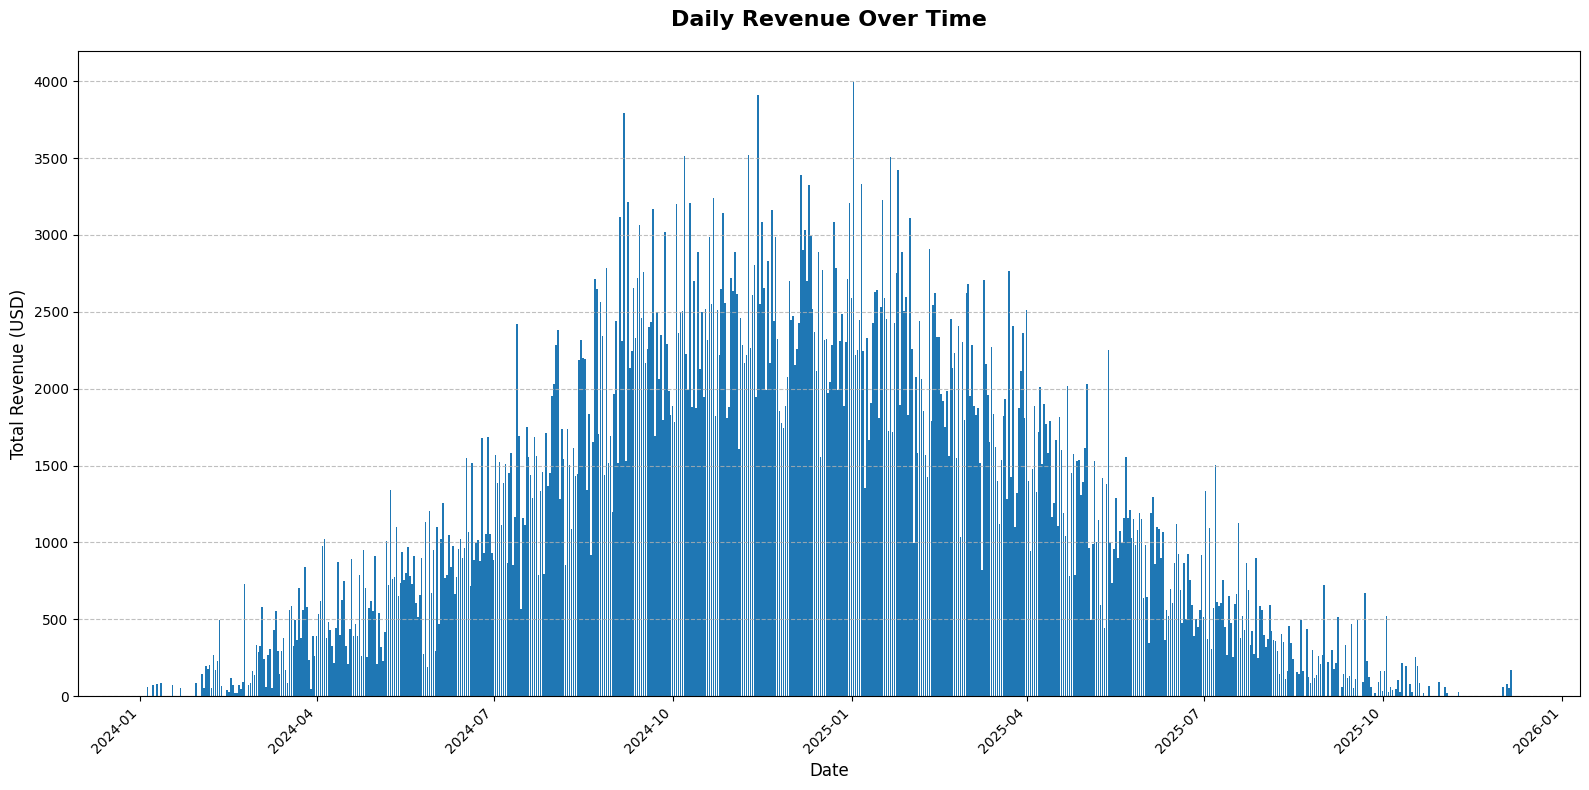

In [54]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))
ax.bar(
    daily_revenue['date'], 
    daily_revenue['daily_revenue'], 
    color='#1f77b4'
)

ax.set_title('Daily Revenue Over Time', fontsize=16, fontweight='bold', pad=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Revenue (USD)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.8, axis='y')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [55]:
import json

dataset_name = "DATA1"
daily_revenue.to_csv(f'daily_revenue_{dataset_name}.csv', index=False)
top_5_revenue_days.to_csv(f'top_5_revenue_{dataset_name}.csv', index=False)

metrics = {
    "unique_users": int(unique_users),
    "unique_author_sets": int(unique_sets_count),
    "most_popular_author": str(most_popular['author_set']),
    "best_buyer_aliases": best_buyer_aliases 
}

with open(f'dashboard_metrics_{dataset_name}.json', 'w') as f:
    json.dump(metrics, f)